In [1]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. Load the dataset
# Ensure the .dta file is in your working directory
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta").dropna()

# 2. Data Preparation
# Create a datetime column for easier filtering (assuming year, month, day, hour exist)
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Define the "Post" dummy: 1 if date is after Jan 1, 2005 (Start of ETS)
df['Post'] = (df['year'] >= 2005).astype(int)

# Define the "Treated" dummy: Peak hours (usually defined as 8am to 8pm)
# The dataset variable 'peak' likely already captures this (1=Peak, 0=Off-Peak)
df['Treated'] = df['peak']

# Create the Interaction Term (The DiD Estimator)
df['Treated_Post'] = df['Treated'] * df['Post']

df


,year,month,day,hour,mg_price,eprice,coal,gas,brent,totalcost,...,ltotalcost2_peak,ltotalcost2_off,ecost2_peak,ecost2_off,lecost2_peak,lecost2_off,date,Post,Treated,Treated_Post
4,2004.0,1.0,1.0,5,16.54,0.00,0.6668,1.3055,1.7566,20.158566,...,0.000000,3.052045,0.000000,0.000000,0.000000,0.000000,2004-01-01 05:00:00,0,0.0,0.0
6,2004.0,1.0,1.0,7,14.54,0.00,0.6668,1.3055,1.7566,21.075415,...,0.000000,3.094465,0.000000,0.000000,0.000000,0.000000,2004-01-01 07:00:00,0,0.0,0.0
10,2004.0,1.0,1.0,11,10.01,0.00,0.6668,1.3055,1.7566,20.546642,...,3.070220,0.000000,0.000000,0.000000,0.000000,0.000000,2004-01-01 11:00:00,0,1.0,0.0
15,2004.0,1.0,1.0,16,10.12,0.00,0.6668,1.3055,1.7566,20.159899,...,3.052108,0.000000,0.000000,0.000000,0.000000,0.000000,2004-01-01 16:00:00,0,1.0,0.0
17,2004.0,1.0,1.0,18,10.22,0.00,0.6668,1.3055,1.7566,19.818497,...,3.035842,0.000000,0.000000,0.000000,0.000000,0.000000,2004-01-01 18:00:00,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30643,2007.0,6.0,30.0,20,31.60,0.14,0.7288,1.4082,4.0270,27.316673,...,3.343451,0.000000,0.051533,0.000000,0.050249,0.000000,2007-06-30 20:00:00,1,1.0,1.0
30644,2007.0,6.0,30.0,21,31.62,0.14,0.7288,1.4082,4.0270,24.073147,...,0.000000,3.221797,0.000000,0.144442,0.000000,0.134917,2007-06-30 21:00:00,1,0.0,0.0
30645,2007.0,6.0,30.0,22,35.00,0.14,0.7288,1.4082,4.0270,26.988102,...,0.000000,3.331779,0.000000,0.049664,0.000000,0.048470,2007-06-30 22:00:00,1,0.0,0.0
30646,2007.0,6.0,30.0,23,40.07,0.14,0.7288,1.4082,4.0270,27.313765,...,0.000000,3.343348,0.000000,0.048624,0.000000,0.047479,2007-06-30 23:00:00,1,0.0,0.0


In [2]:
# 3. Define the Regression Equation
# We control for supply costs (coal, gas, oil), weather (wind, temp), 
# and use Fixed Effects (C(var)) for seasonality.
regression_formula = r"""mg_price ~ Treated_Post + Treated + Post + coal + gas + brent + windx + temp + humid + C(month) + C(day) + C(hour)"""

# 4. Run the Regression
# We use Newey-West standard errors (cov_type='HAC') to account for 
# the high-frequency serial correlation/volatility in electricity prices.
model = smf.ols(regression_formula, data=df)
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 24})

# 5. Output results
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:                mg_price   R-squared:                       0.522
Model:                             OLS   Adj. R-squared:                  0.520
Method:                  Least Squares   F-statistic:                     51.52
Date:              mer., 14 janv. 2026   Prob (F-statistic):               0.00
Time:                         17:00:50   Log-Likelihood:                -65683.
No. Observations:                17309   AIC:                         1.315e+05
Df Residuals:                    17236   BIC:                         1.321e+05
Df Model:                           72                                         
Covariance Type:                   HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           40.6502   

e:\anaconda3\envs\economics_for_challenging_times\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 73, but rank is 72
  warnings.warn('covariance of constraints does not have full '


In [46]:
regression_formula = r"""mg_price ~ Treated_Post + Treated + Post + coal + gas + brent + windx + temp + humid"""

# 4. Run the Regression
# We use Newey-West standard errors (cov_type='HAC') to account for 
# the high-frequency serial correlation/volatility in electricity prices.
model = smf.ols(regression_formula, data=df)
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 24})

# 5. Output results
print(results.summary())

                             OLS Regression Results                            
Dep. Variable:                mg_price   R-squared:                       0.382
Model:                             OLS   Adj. R-squared:                  0.381
Method:                  Least Squares   F-statistic:                     225.7
Date:              ven., 02 janv. 2026   Prob (F-statistic):               0.00
Time:                         18:17:28   Log-Likelihood:                -67907.
No. Observations:                17309   AIC:                         1.358e+05
Df Residuals:                    17299   BIC:                         1.359e+05
Df Model:                            9                                         
Covariance Type:                   HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       26.9919      6.109    

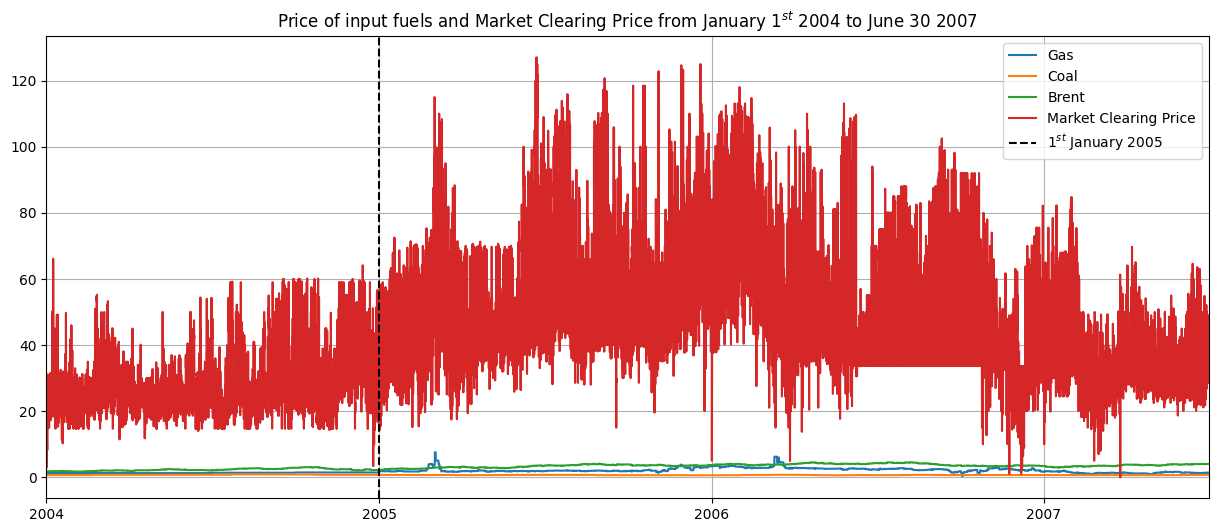

In [9]:
import matplotlib.pyplot as plt
import numpy as np
df2 = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")
x = np.linspace(0, df2.shape[0]-1, df2.shape[0])
fig, ax = plt.subplots(figsize=(15, 6))
plt.plot(x, df2["gas"], label="Gas")
plt.plot(x, df2["coal"], label="Coal")
plt.plot(x, df2["brent"], label="Brent")
plt.plot(x, df2["mg_price"], label="Market Clearing Price")
plt.axvline(8784, 0, 8, color="k", ls="--", label="1$^{st}$ January 2005")
# plt.ylim(0, 8)
plt.xlim(0, df2.shape[0])
plt.xticks([0, 8784, 8784+8760, 8784+8760+8760], ["2004", "2005", "2006", "2007"])
plt.grid()
plt.legend()
plt.title("Price of input fuels and Market Clearing Price from January $1^{st}$ 2004 to June 30 2007")
plt.show()

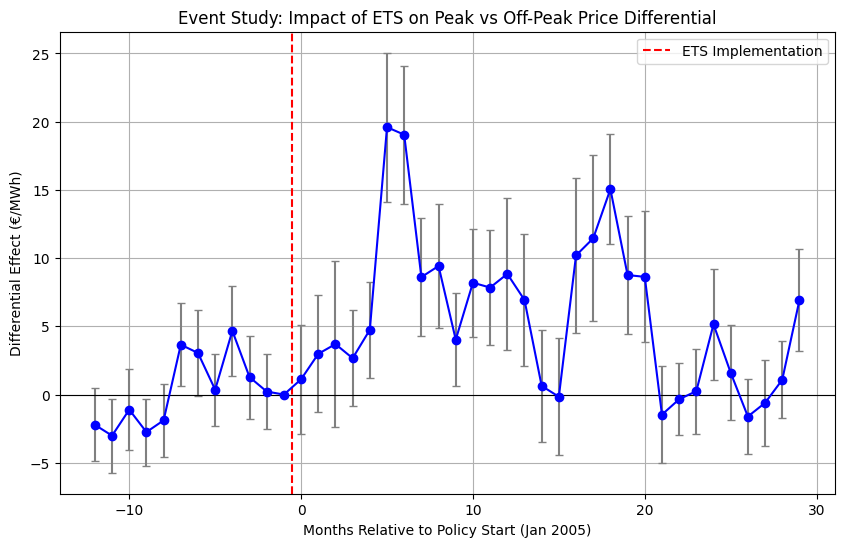

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Load and Prepare Data
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Create a time index (months relative to Jan 2005)
# Jan 2005 becomes index 0; Dec 2004 becomes -1
df['time_idx'] = (df['year'] - 2005) * 12 + (df['month'] - 1)

# Ensure 'peak' is treated as a categorical/integer variable
df['peak'] = df['peak'].astype(int)

# 2. Define the Event Study Regression
# We interact C(time_idx) with C(peak).
# We set reference=-1 (Dec 2004) so all coefficients are relative to the month before policy.
# 'windx' is the wind variable in your dataset.
formula = """
    mg_price ~ C(time_idx, Treatment(reference=-1)) * C(peak) + 
               coal + gas + brent + 
               windx + temp + humid + 
               C(day) + C(hour)
"""

# 3. Run Regression with HAC Standard Errors (Newey-West, lags=24)
model = smf.ols(formula, data=df)
results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 24})

# 4. Extract and Plot Coefficients
# (Logic to filter parameters starting with 'C(time_idx' and ending in ':C(peak)[T.1]')
params = results.params
conf_int = results.conf_int()

# Filter for the interaction terms of interest
coeffs = []
indices = []
errors = []

# Loop through time indices to extract matching params
for t in sorted(df['time_idx'].unique()):
    if t == -1:
        indices.append(t); coeffs.append(0); errors.append(0)
        continue
    
    # Construct the parameter name statsmodels uses
    key = f"C(time_idx, Treatment(reference=-1))[T.{t}]:C(peak)[T.1]"
    
    if key in params:
        indices.append(t)
        coeffs.append(params[key])
        # Error for plotting (upper CI - mean)
        errors.append(conf_int.loc[key][1] - params[key])

# Plotting
plt.figure(figsize=(10, 6))
plt.errorbar(indices, coeffs, yerr=errors, fmt='-o', color='b', ecolor='gray', capsize=3)
plt.axvline(x=-0.5, color='red', linestyle='--', label='ETS Implementation')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Event Study: Impact of ETS on Peak vs Off-Peak Price Differential')
plt.xlabel('Months Relative to Policy Start (Jan 2005)')
plt.ylabel('Differential Effect (€/MWh)')
plt.grid()
plt.legend()
plt.savefig('event_study_plot.png')

In [3]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load the dataset
file_path = r"Initial code\stata_data\data_regressions_passthrough.dta"
df = pd.read_stata(file_path)

# 1. Prepare Data
# Create a datetime column for ordering and plotting
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Collapse to hourly level (Market Clearing Price is market-wide, not firm-specific)
# We take the mean of variables that are common across firms (price, weather, fuels)
hourly_df = df.groupby('date').agg({
    'mg_price': 'mean',
    'coal': 'mean',
    'gas': 'mean',
    'brent': 'mean',
    'windx': 'mean',
    'temp': 'mean',
    'humid': 'mean',
    'totalcost': 'mean', # Proxy for economic activity/demand
    'rd': 'max',         # Royal Decree dummy (0 or 1 for the period)
    'year': 'first',
    'month': 'first',
    'day': 'first',      # This is day of month
    'hour': 'first'
}).reset_index()

# Add Day of Week for Fixed Effects (0=Monday, 6=Sunday)
hourly_df['weekday'] = hourly_df['date'].dt.dayofweek

# 2. Define Event Variables
# Event 1: ETS Introduction (Starts Jan 2005)
# In a Time Series Event Study, the "Interaction" is the Post-Event Dummy.
hourly_df['Post_ETS'] = (hourly_df['year'] >= 2005).astype(int)

# Event 2: Royal Decree (Already in 'rd' column)
hourly_df['Post_RD'] = hourly_df['rd']

# 3. Define Regression Formula
# We include Fixed Effects using the 'C()' categorical operator
# Controls: Fuel costs, Renewables (wind), Demand (totalcost), Weather (temp, humid)
formula_ets = (
    "mg_price ~ Post_ETS + coal + gas + brent + "
    "windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)

formula_rd = (
    "mg_price ~ Post_RD + coal + gas + brent + "
    "windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)

# 4. Run Regressions
# We use fit(cov_type='HAC', cov_kwds={'maxlags':24}) to account for 
# high-frequency volatility and daily serial correlation (24 hours).

print("--- Event Study 1: ETS Introduction ---")
model_ets = smf.ols(formula_ets, data=hourly_df)
results_ets = model_ets.fit(cov_type='HAC', cov_kwds={'maxlags': 24})
print(results_ets.summary())

print("\n--- Event Study 2: Royal Decree (RD) ---")
model_rd = smf.ols(formula_rd, data=hourly_df)
results_rd = model_rd.fit(cov_type='HAC', cov_kwds={'maxlags': 24})
print(results_rd.summary())

# Explanation of Coefficients
print("\n--- Interpretation ---")
print(f"Impact of ETS (Coeff on Post_ETS): {results_ets.params['Post_ETS']:.4f}")
print(f"Impact of Royal Decree (Coeff on Post_RD): {results_rd.params['Post_RD']:.4f}")

--- Event Study 1: ETS Introduction ---
                            OLS Regression Results                            
Dep. Variable:               mg_price   R-squared:                       0.619
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     105.4
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        23:35:33   Log-Likelihood:                -64095.
No. Observations:               17416   AIC:                         1.283e+05
Df Residuals:                   17367   BIC:                         1.287e+05
Df Model:                          48                                         
Covariance Type:                  HAC                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------


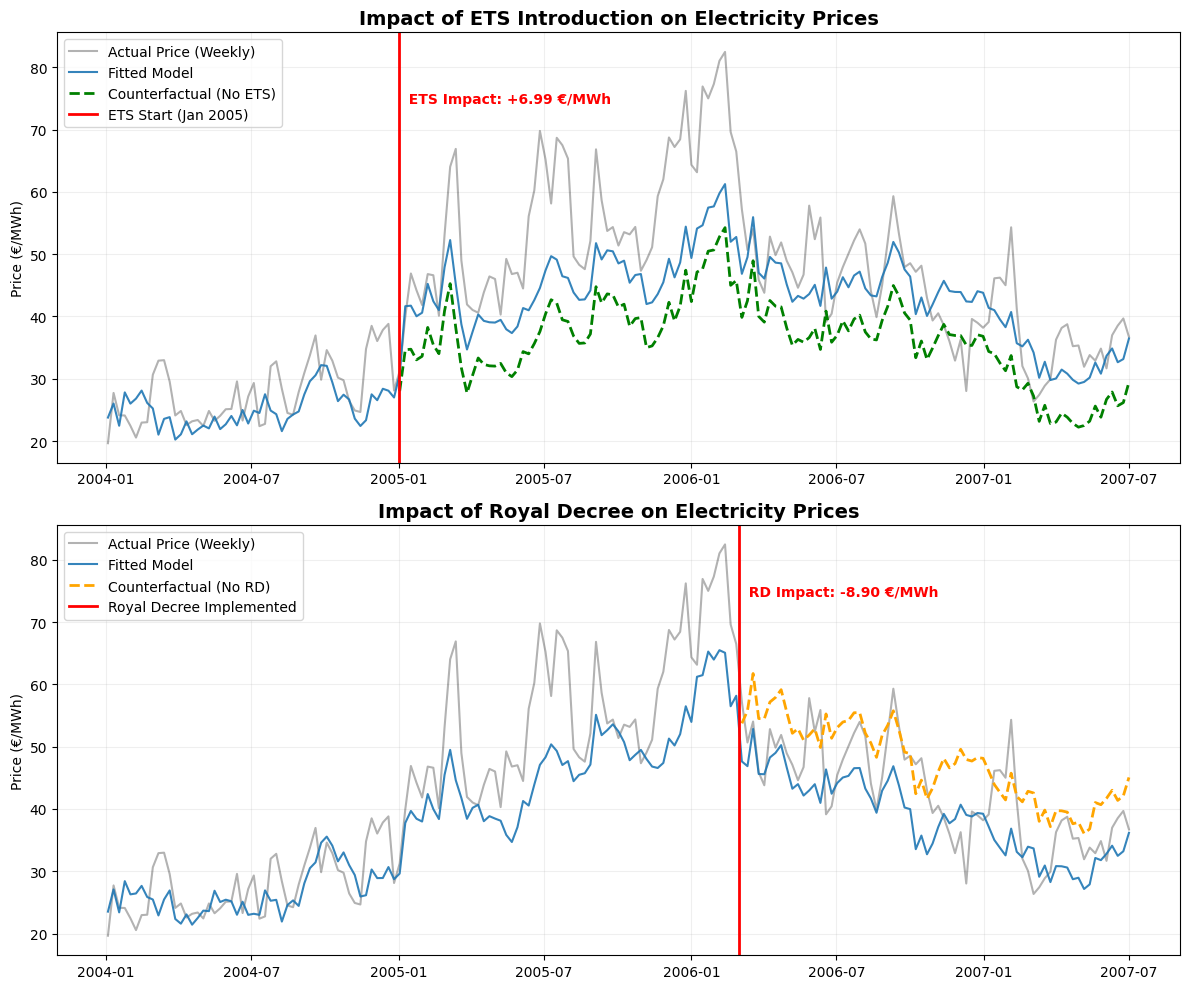

In [4]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Load Data
# Note: Ensure the file is in the current working directory
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# 2. Aggregate to Hourly (Market Level)
# We calculate the mean of market variables to create a time-series dataset
hourly_df = df.groupby('date').agg({
    'mg_price': 'mean',
    'coal': 'mean',
    'gas': 'mean',
    'brent': 'mean',
    'windx': 'mean',
    'temp': 'mean',
    'humid': 'mean',
    'totalcost': 'mean',
    'rd': 'max', # Indicator variable
    'year': 'first',
    'month': 'first'
}).reset_index()

# Add Time Features for Fixed Effects
hourly_df['weekday'] = hourly_df['date'].dt.dayofweek
hourly_df['hour'] = hourly_df['date'].dt.hour

# Define Event Indicators
hourly_df['Post_ETS'] = (hourly_df['year'] >= 2005).astype(int)
hourly_df['Post_RD'] = hourly_df['rd']

# 3. Fit Models (using Newey-West SEs for inference, though OLS fit is same for plotting)
formula_ets = (
    "mg_price ~ Post_ETS + coal + gas + brent + "
    "windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)
model_ets = smf.ols(formula_ets, data=hourly_df).fit()

formula_rd = (
    "mg_price ~ Post_RD + coal + gas + brent + "
    "windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)
model_rd = smf.ols(formula_rd, data=hourly_df).fit()

# 4. Calculate Fitted Values and Counterfactuals
# Fitted: The model's prediction including the policy effect
hourly_df['fitted_ets'] = model_ets.fittedvalues
hourly_df['fitted_rd'] = model_rd.fittedvalues

# Counterfactual: The prediction IF the policy effect were zero (removing the coefficient impact)
beta_ets = model_ets.params['Post_ETS']
hourly_df['effect_ets'] = beta_ets * hourly_df['Post_ETS']
hourly_df['counterfactual_ets'] = hourly_df['fitted_ets'] - hourly_df['effect_ets']

beta_rd = model_rd.params['Post_RD']
hourly_df['effect_rd'] = beta_rd * hourly_df['Post_RD']
hourly_df['counterfactual_rd'] = hourly_df['fitted_rd'] - hourly_df['effect_rd']

# Resample to Weekly Frequency for cleaner plotting (smoothing out hourly volatility)
weekly_df = hourly_df.set_index('date').resample('W').mean()

# Identify Event Dates for Plotting
ets_date = pd.Timestamp('2005-01-01')
rd_date = hourly_df[hourly_df['rd'] == 1]['date'].min() # First instance of RD

# 5. Generate Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Plot 1: ETS Introduction ---
ax1 = axes[0]
ax1.plot(weekly_df.index, weekly_df['mg_price'], color='black', alpha=0.3, label='Actual Price (Weekly)')
ax1.plot(weekly_df.index, weekly_df['fitted_ets'], color='#1f77b4', alpha=0.9, linewidth=1.5, label='Fitted Model')
# Plot Counterfactual only after event
mask_ets = weekly_df.index >= ets_date
ax1.plot(weekly_df.index[mask_ets], weekly_df['counterfactual_ets'][mask_ets], 
         color='green', linestyle='--', linewidth=2, label='Counterfactual (No ETS)')
ax1.axvline(ets_date, color='red', linestyle='-', linewidth=2, label='ETS Start (Jan 2005)')

ax1.set_title('Impact of ETS Introduction on Electricity Prices', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (€/MWh)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)
ax1.text(ets_date, weekly_df['mg_price'].max()*0.9, f'  ETS Impact: {beta_ets:+.2f} €/MWh', color='red', fontweight='bold')

# --- Plot 2: Royal Decree (RD) ---
ax2 = axes[1]
ax2.plot(weekly_df.index, weekly_df['mg_price'], color='black', alpha=0.3, label='Actual Price (Weekly)')
ax2.plot(weekly_df.index, weekly_df['fitted_rd'], color='#1f77b4', alpha=0.9, linewidth=1.5, label='Fitted Model')
# Plot Counterfactual only after event
if pd.notnull(rd_date):
    mask_rd = weekly_df.index >= rd_date
    ax2.plot(weekly_df.index[mask_rd], weekly_df['counterfactual_rd'][mask_rd], 
             color='orange', linestyle='--', linewidth=2, label='Counterfactual (No RD)')
    ax2.axvline(rd_date, color='red', linestyle='-', linewidth=2, label='Royal Decree Implemented')

ax2.set_title('Impact of Royal Decree on Electricity Prices', fontsize=14, fontweight='bold')
ax2.set_ylabel('Price (€/MWh)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.2)
ax2.text(rd_date, weekly_df['mg_price'].max()*0.9, f'  RD Impact: {beta_rd:+.2f} €/MWh', color='red', fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
np.average(df["mg_price"][8784:].to_numpy())*0.14, np.average(df["mg_price"][18960:].to_numpy())-np.average(df["mg_price"][8784:].to_numpy())

(np.float64(6.859150933040615), np.float64(-6.406939171664895))

In [12]:
df

,year,month,day,hour,mg_price,eprice,coal,gas,brent,totalcost,...,yq,totalcost2_peak,totalcost2_off,ltotalcost2_peak,ltotalcost2_off,ecost2_peak,ecost2_off,lecost2_peak,lecost2_off,date
0,2004.0,1.0,1.0,1,28.99,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2004-01-01 01:00:00
1,2004.0,1.0,1.0,2,28.23,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2004-01-01 02:00:00
2,2004.0,1.0,1.0,3,25.48,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2004-01-01 03:00:00
3,2004.0,1.0,1.0,4,23.00,0.00,0.6668,1.3055,1.7566,NaN,...,1.0,0.000000,19.813829,0.000000,3.035618,0.000000,0.000000,0.000000,0.000000,2004-01-01 04:00:00
4,2004.0,1.0,1.0,5,16.54,0.00,0.6668,1.3055,1.7566,20.158566,...,1.0,0.000000,20.158566,0.000000,3.052045,0.000000,0.000000,0.000000,0.000000,2004-01-01 05:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30643,2007.0,6.0,30.0,20,31.60,0.14,0.7288,1.4082,4.0270,27.316673,...,14.0,27.316673,0.000000,3.343451,0.000000,0.051533,0.000000,0.050249,0.000000,2007-06-30 20:00:00
30644,2007.0,6.0,30.0,21,31.62,0.14,0.7288,1.4082,4.0270,24.073147,...,14.0,0.000000,24.073147,0.000000,3.221797,0.000000,0.144442,0.000000,0.134917,2007-06-30 21:00:00
30645,2007.0,6.0,30.0,22,35.00,0.14,0.7288,1.4082,4.0270,26.988102,...,14.0,0.000000,26.988102,0.000000,3.331779,0.000000,0.049664,0.000000,0.048470,2007-06-30 22:00:00
30646,2007.0,6.0,30.0,23,40.07,0.14,0.7288,1.4082,4.0270,27.313765,...,14.0,0.000000,27.313765,0.000000,3.343348,0.000000,0.048624,0.000000,0.047479,2007-06-30 23:00:00


In [17]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Load and Prepare Data
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Aggregate to Hourly Level (Market Level)
hourly_df = df.groupby('date').agg({
    'mg_price': 'mean',
    'coal': 'mean',
    'gas': 'mean',
    'brent': 'mean',
    'windx': 'mean',
    'temp': 'mean',
    'humid': 'mean',
    'totalcost': 'mean',
    'rd': 'max',
    'year': 'first',
    'month': 'first',
    'day': 'first',
    'hour': 'first'
}).reset_index()

# Add time features
hourly_df['weekday'] = hourly_df['date'].dt.dayofweek

# 2. Feature Engineering

# a) Event Dummies (Joint Model)
hourly_df['Post_ETS'] = (hourly_df['year'] >= 2005).astype(int)
hourly_df['Post_RD'] = hourly_df['rd']

# b) Non-Linearity (Squared Demand)
# Electricity supply curves are convex; linear models might bias results at peak/off-peak.
hourly_df['totalcost_sq'] = hourly_df['totalcost'] ** 2
hourly_df['totalcost_cu'] = hourly_df['totalcost'] ** 3

# c) Anticipation (Leads for ETS)
# Check for effects in Q4 2004 (Oct, Nov, Dec) before Jan 2005 start.
hourly_df['Lead_Dec04'] = ((hourly_df['year'] == 2004) & (hourly_df['month'] == 12)).astype(int)
hourly_df['Lead_Nov04'] = ((hourly_df['year'] == 2004) & (hourly_df['month'] == 11)).astype(int)
hourly_df['Lead_Oct04'] = ((hourly_df['year'] == 2004) & (hourly_df['month'] == 10)).astype(int)

# 3. Define and Run Models

# Model 1: Joint Specification (ETS + RD together)
# Solves the overlap issue where RD period was "Post-ETS".
formula_joint = (
    "mg_price ~ Post_ETS + Post_RD + "
    "coal + gas + brent + windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)

# Model 2: Non-Linear Supply (Adding squared and cubic demand)
formula_nonlinear = (
    "mg_price ~ Post_ETS + Post_RD + "
    "coal + gas + brent + windx + totalcost + totalcost_sq + totalcost_cu + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)

# Model 3: Anticipation Effects (Adding Leads)
# If Lead terms are significant, the market priced in the event early.
formula_leads = (
    "mg_price ~ Post_ETS + Post_RD + "
    "Lead_Oct04 + Lead_Nov04 + Lead_Dec04 + "
    "coal + gas + brent + windx + totalcost + totalcost_sq + temp + humid + "
    "C(month) + C(weekday) + C(hour)"
)

def run_and_print(name, formula, data):
    print(f"\n--- {name} ---")
    model = smf.ols(formula, data=data)
    # Newey-West Standard Errors (HAC) with 24 lags (daily serial correlation)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 24})
    
    # Print coefficients of interest
    cols = ['Post_ETS', 'Post_RD', 'Lead_Dec04', 'Lead_Nov04', 'Lead_Oct04', 'totalcost', 'totalcost_sq']
    for var in cols:
        if var in results.params:
            coef = results.params[var]
            se = results.bse[var]
            pval = results.pvalues[var]
            stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
            print(f"{var:12}: {coef:6.2f} (SE: {se:.2f}) {stars}")
    return results

# Execution
res_joint = run_and_print("Model 1: Joint Specification", formula_joint, hourly_df)
res_nl = run_and_print("Model 2: Non-Linear Controls", formula_nonlinear, hourly_df)
res_leads = run_and_print("Model 3: Anticipation Effects", formula_leads, hourly_df)


--- Model 1: Joint Specification ---
Post_ETS    :   8.36 (SE: 0.94) ***
Post_RD     :  -9.40 (SE: 0.69) ***
totalcost   :   0.33 (SE: 0.03) ***

--- Model 2: Non-Linear Controls ---
Post_ETS    :   8.53 (SE: 1.03) ***
Post_RD     :  -9.04 (SE: 0.68) ***
totalcost   :  -0.07 (SE: 0.21) 
totalcost_sq:   0.01 (SE: 0.00) **

--- Model 3: Anticipation Effects ---
Post_ETS    :   8.01 (SE: 1.06) ***
Post_RD     :  -8.90 (SE: 0.68) ***
Lead_Dec04  :   5.95 (SE: 2.02) ***
Lead_Nov04  :   3.83 (SE: 1.96) *
Lead_Oct04  :  -2.10 (SE: 1.28) 
totalcost   :   0.55 (SE: 0.08) ***
totalcost_sq:  -0.00 (SE: 0.00) **


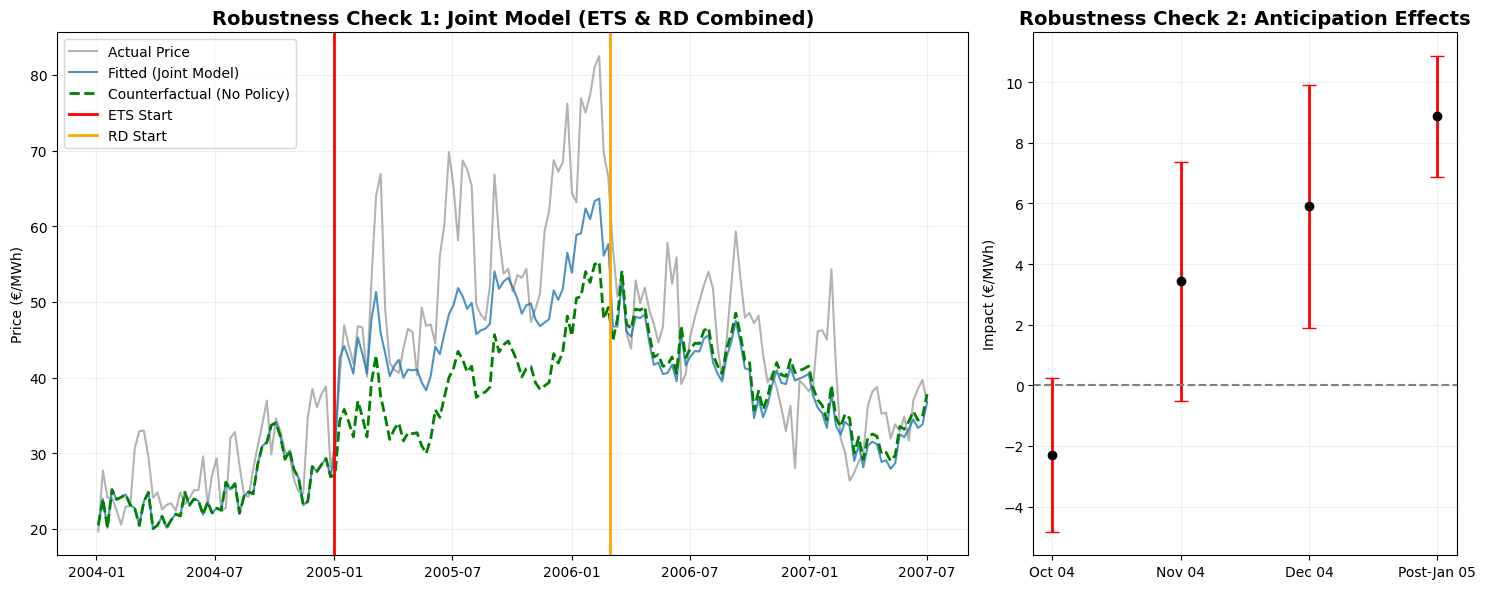

In [4]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Prep
df = pd.read_stata(r"Initial code\stata_data\data_regressions_passthrough.dta")
df['date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Aggregate to Hourly Market Level
hourly_df = df.groupby('date').agg({
    'mg_price': 'mean', 'coal': 'mean', 'gas': 'mean', 'brent': 'mean',
    'windx': 'mean', 'temp': 'mean', 'humid': 'mean', 'totalcost': 'mean',
    'rd': 'max', 'year': 'first', 'month': 'first', 'hour': 'first'
}).reset_index()

hourly_df['weekday'] = hourly_df['date'].dt.dayofweek
hourly_df['Post_ETS'] = (hourly_df['year'] >= 2005).astype(int)
hourly_df['Post_RD'] = hourly_df['rd']

# Create Anticipation Leads
hourly_df['Lead_Oct04'] = ((hourly_df['year'] == 2004) & (hourly_df['month'] == 10)).astype(int)
hourly_df['Lead_Nov04'] = ((hourly_df['year'] == 2004) & (hourly_df['month'] == 11)).astype(int)
hourly_df['Lead_Dec04'] = ((hourly_df['year'] == 2004) & (hourly_df['month'] == 12)).astype(int)

# 2. Refit Models for Plotting
# Model 1: Joint Specification (ETS + RD)
res_joint = smf.ols(
    "mg_price ~ Post_ETS + Post_RD + coal + gas + brent + windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)", 
    data=hourly_df
).fit()

# Model 3: Anticipation (Dynamic Effects)
res_leads = smf.ols(
    "mg_price ~ Post_ETS + Post_RD + Lead_Oct04 + Lead_Nov04 + Lead_Dec04 + "
    "coal + gas + brent + windx + totalcost + temp + humid + "
    "C(month) + C(weekday) + C(hour)", 
    data=hourly_df
).fit(cov_type='HAC', cov_kwds={'maxlags': 24})

# 3. Create Plots
fig = plt.figure(figsize=(15, 6))
gs = fig.add_gridspec(1, 3)

# --- Plot A: Joint Model Counterfactuals ---
ax1 = fig.add_subplot(gs[0, :2])

# Calculate fitted and counterfactual (removing BOTH policy effects)
beta_ets = res_joint.params['Post_ETS']
beta_rd = res_joint.params['Post_RD']
hourly_df['fitted_joint'] = res_joint.fittedvalues
hourly_df['effect_joint'] = (beta_ets * hourly_df['Post_ETS']) + (beta_rd * hourly_df['Post_RD'])
hourly_df['counterfactual_joint'] = hourly_df['fitted_joint'] - hourly_df['effect_joint']

# Resample to weekly for cleaner lines
weekly_plot = hourly_df.set_index('date').resample('W').mean()

ax1.plot(weekly_plot.index, weekly_plot['mg_price'], color='black', alpha=0.3, label='Actual Price')
ax1.plot(weekly_plot.index, weekly_plot['fitted_joint'], color='#1f77b4', alpha=0.8, label='Fitted (Joint Model)')
ax1.plot(weekly_plot.index, weekly_plot['counterfactual_joint'], color='green', linestyle='--', linewidth=2, label='Counterfactual (No Policy)')

# Mark Events
ax1.axvline(pd.Timestamp('2005-01-01'), color='red', linestyle='-', linewidth=2, label='ETS Start')
rd_start = hourly_df[hourly_df['rd']==1]['date'].min()
if pd.notnull(rd_start):
    ax1.axvline(rd_start, color='orange', linestyle='-', linewidth=2, label='RD Start')

ax1.set_title('Robustness Check 1: Joint Model (ETS & RD Combined)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Price (€/MWh)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# # --- Plot B: Non-Linear Supply Curve ---
# ax2 = fig.add_subplot(gs[1, 0])
# # Plot scatter of Price vs Demand with a Cubic Fit line
# sns.regplot(x=hourly_df['totalcost'], y=hourly_df['mg_price'], 
#             scatter_kws={'alpha':0.05, 'color':'gray', 's':10}, 
#             line_kws={'color':'red', 'linewidth':2}, 
#             order=3, # Polynomial fit
#             ax=ax2, label='Cubic Fit')

# ax2.set_title('Robustness Check 2: Non-Linear Supply Curve', fontsize=14, fontweight='bold')
# ax2.set_xlabel('Demand (Total Cost)')
# ax2.set_ylabel('Price (€/MWh)')
# ax2.legend()
# ax2.grid(True, alpha=0.2)

# --- Plot C: Anticipation Effects ---
ax3 = fig.add_subplot(gs[0, 2])

# Extract coefficients for leads and post
vars = ['Lead_Oct04', 'Lead_Nov04', 'Lead_Dec04', 'Post_ETS']
coeffs = res_leads.params[vars]
cis = res_leads.conf_int().loc[vars]
yerr = coeffs - cis[0] # Calculate error bar length

# Plot
labels = ['Oct 04', 'Nov 04', 'Dec 04', 'Post-Jan 05']
ax3.errorbar(range(len(labels)), coeffs, yerr=yerr, fmt='o', color='black', ecolor='red', capsize=5, elinewidth=2)
ax3.axhline(0, color='gray', linestyle='--')
ax3.set_xticks(range(len(labels)))
ax3.set_xticklabels(labels)
ax3.set_title('Robustness Check 2: Anticipation Effects', fontsize=14, fontweight='bold')
ax3.set_ylabel('Impact (€/MWh)')
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()